In [11]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
import json
import warnings
warnings.filterwarnings('ignore')

# Initialize SHAP JavaScript visualization libraries
shap.initjs()

# Loading the engineered dataset and feature definitions
df = pd.read_csv('../data/processed/FD001_with_rul.csv')
with open('../data/processed/feature_cols.json') as f:
    feature_cols = json.load(f)

# Reconstructing the exact test split used in the baseline modeling phase to ensure consistency
engines = df['unit_id'].unique()
np.random.seed(42)
test_engines = np.random.choice(engines, size=int(0.2 * len(engines)), replace=False)
train_mask = ~df['unit_id'].isin(test_engines)
test_mask  =  df['unit_id'].isin(test_engines)

X_train = df[train_mask][feature_cols]
X_test  = df[test_mask][feature_cols]
y_test  = df[test_mask]['RUL']

# Loading the pre-trained XGBoost regressor model
model = xgb.XGBRegressor()
model.load_model('../results/models/xgboost.json')

print(f"Testing set loaded successfully. Shape: {X_test.shape}")

Testing set loaded successfully. Shape: (4070, 87)


In [3]:
# Initializing the SHAP TreeExplainer, optimized for tree-based models like XGBoost
explainer = shap.TreeExplainer(model)

# Sampling the test set to optimize computational performance during SHAP value extraction
np.random.seed(0)
sample_idx = np.random.choice(len(X_test), size=min(1000, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx].reset_index(drop=True)
y_sample = y_test.iloc[sample_idx].reset_index(drop=True)

# Computing SHAP values for the sampled dataset
shap_values = explainer(X_sample)
print(f"SHAP values computed. Tensor shape: {shap_values.values.shape}")

SHAP values computed. Tensor shape: (1000, 87)


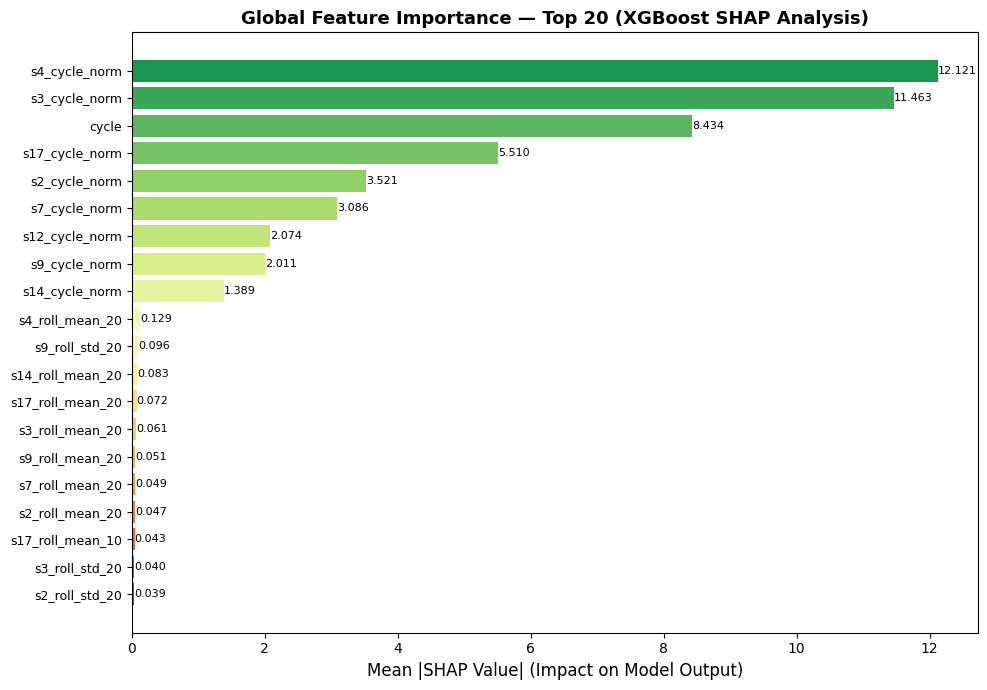

Top 5 driving features identified: ['s4_cycle_norm', 's3_cycle_norm', 'cycle', 's17_cycle_norm', 's2_cycle_norm']


In [4]:
# Aggregating absolute SHAP values to determine global feature importance
mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

top20 = mean_abs_shap.head(20)

# Visualizing the Top 20 globally most impactful features
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top20)))
bars = ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])

ax.set_xlabel('Mean |SHAP Value| (Impact on Model Output)', fontsize=12)
ax.set_title('Global Feature Importance — Top 20 (XGBoost SHAP Analysis)', fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=9)

# Annotating bar charts with exact SHAP magnitude values
for bar, val in zip(bars, top20.values[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../results/shap_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Exporting the prioritized feature list for production monitoring
top20.to_csv('../results/shap_top20_features.csv', header=['mean_abs_shap'])
print(f"Top 5 driving features identified: {top20.head().index.tolist()}")

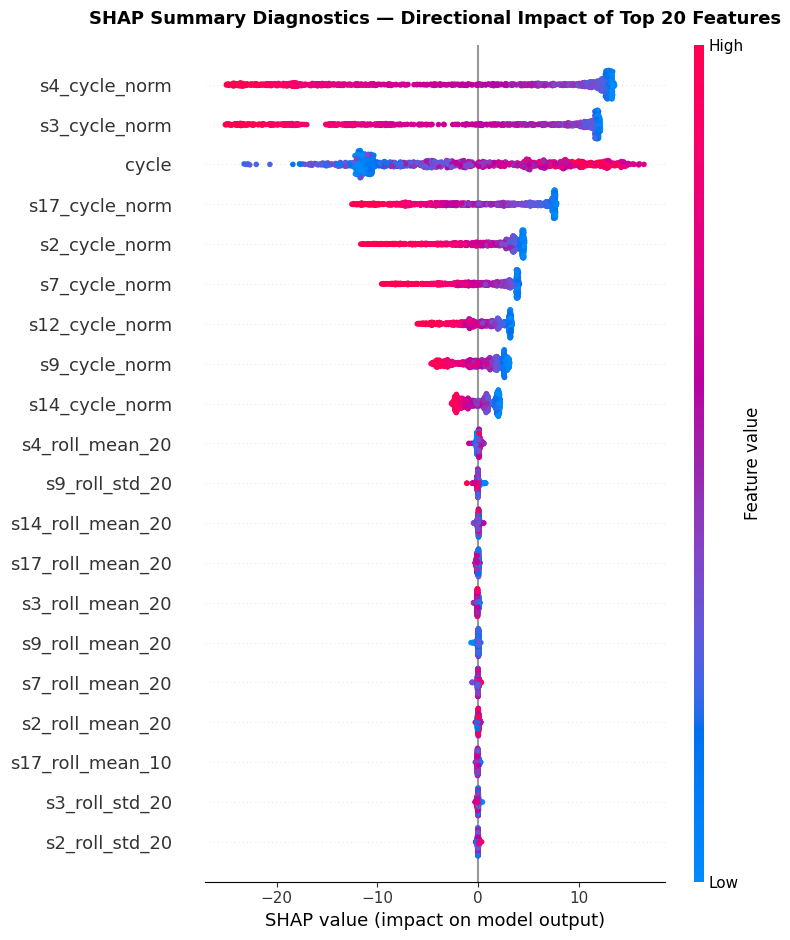

In [5]:
# Generating a Beeswarm plot to analyze the directionality and distribution of feature impacts
top20_features = top20.index.tolist()
top20_idx = [feature_cols.index(f) for f in top20_features]

shap_top20 = shap.Explanation(
    values=shap_values.values[:, top20_idx],
    base_values=shap_values.base_values,
    data=X_sample[top20_features].values,
    feature_names=top20_features
)

plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_top20, max_display=20, show=False)
plt.title('SHAP Summary Diagnostics — Directional Impact of Top 20 Features', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../results/shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Isolating specific engine states (Critical, Warning, Normal) for local interpretation
critical_idx = int(y_sample[y_sample < 20].index[0]) if (y_sample < 20).any() else 0
warning_idx  = int(y_sample[(y_sample >= 30) & (y_sample <= 60)].index[0]) if ((y_sample >= 30) & (y_sample <= 60)).any() else 1
normal_idx   = int(y_sample[y_sample > 90].index[0]) if (y_sample > 90).any() else 2

for label, idx in [('CRITICAL (RUL < 20)', critical_idx),
                   ('WARNING (30 <= RUL <= 60)', warning_idx),
                   ('NORMAL (RUL > 90)', normal_idx)]:
    pred = model.predict(X_sample.iloc[[idx]])[0]
    actual = y_sample.iloc[idx]
    print(f'{label:25s} | Actual RUL: {actual:3.0f} | Predicted RUL: {pred:5.1f}')

CRITICAL (RUL < 20)       | Actual RUL:  10 | Predicted RUL:  10.0
WARNING (30 <= RUL <= 60) | Actual RUL:  46 | Predicted RUL:  46.7
NORMAL (RUL > 90)         | Actual RUL: 125 | Predicted RUL: 125.2


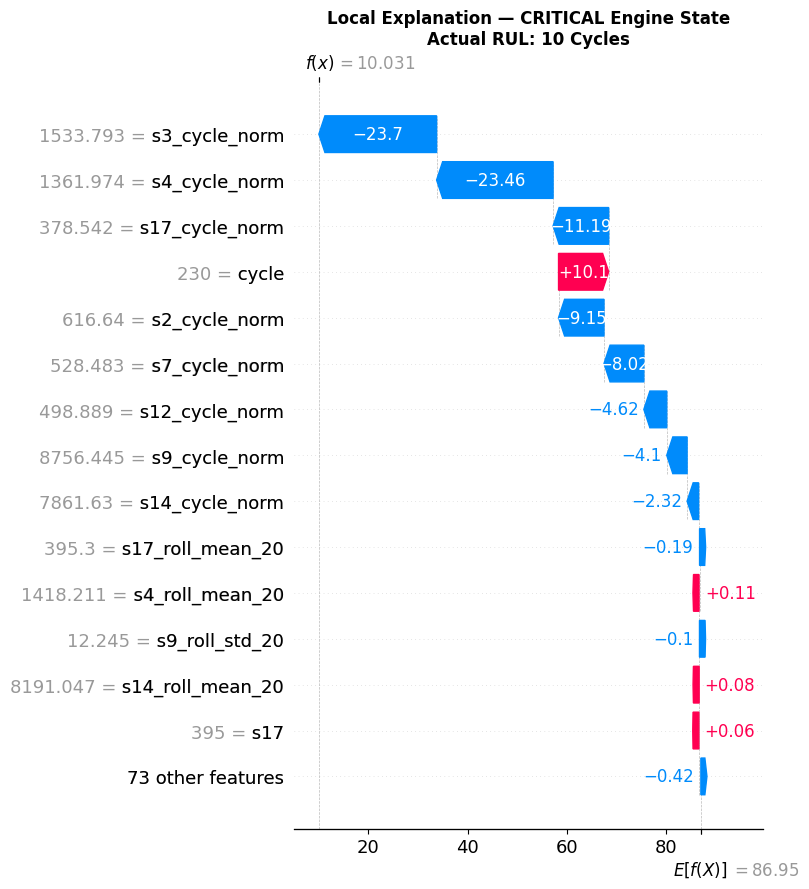

In [7]:
# Local SHAP Waterfall Analysis for a Critical State Engine (Imminent Failure)
shap_critical = shap.Explanation(
    values=shap_values.values[critical_idx],
    base_values=shap_values.base_values[critical_idx],
    data=X_sample.iloc[critical_idx].values,
    feature_names=feature_cols
)
plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_critical, max_display=15, show=False)
plt.title(f'Local Explanation — CRITICAL Engine State\nActual RUL: {y_sample.iloc[critical_idx]:.0f} Cycles',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/shap_waterfall_critical.png', dpi=150, bbox_inches='tight')
plt.show()

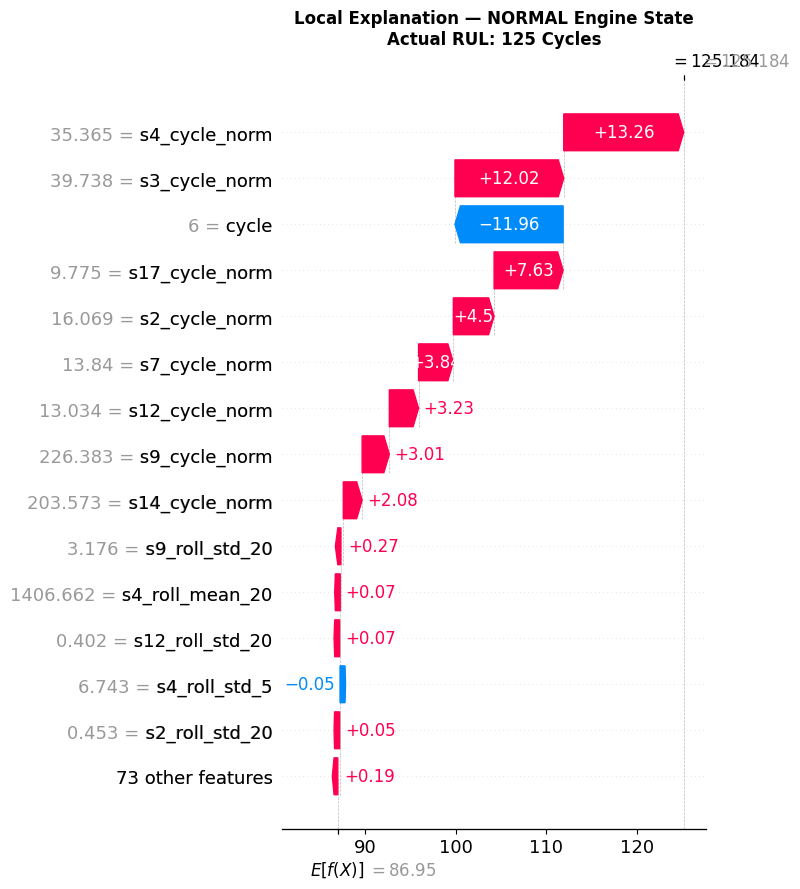

In [8]:
# Local SHAP Waterfall Analysis for a Normal State Engine (Healthy)
shap_normal = shap.Explanation(
    values=shap_values.values[normal_idx],
    base_values=shap_values.base_values[normal_idx],
    data=X_sample.iloc[normal_idx].values,
    feature_names=feature_cols
)
plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_normal, max_display=15, show=False)
plt.title(f'Local Explanation — NORMAL Engine State\nActual RUL: {y_sample.iloc[normal_idx]:.0f} Cycles',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/shap_waterfall_normal.png', dpi=150, bbox_inches='tight')
plt.show()

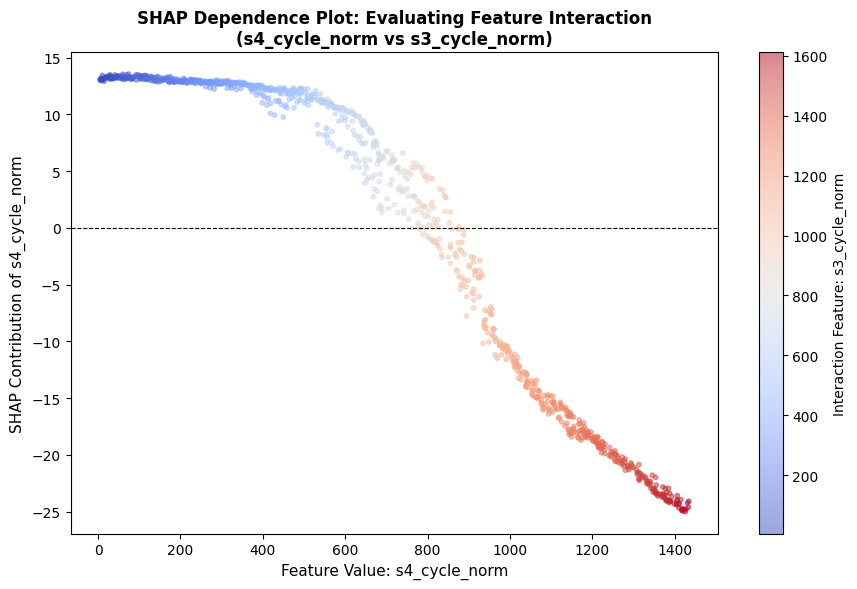

In [9]:
# Analyzing feature interaction via SHAP Dependence Plot
# Mapping the #1 most important feature colored by the #2 most important feature
top1 = top20_features[0]
top2 = top20_features[1]

top1_idx = feature_cols.index(top1)
top2_idx = feature_cols.index(top2)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    X_sample[top1],
    shap_values.values[:, top1_idx],
    c=X_sample[top2],
    cmap='coolwarm', alpha=0.5, s=10
)
plt.colorbar(sc, ax=ax, label=f'Interaction Feature: {top2}')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

ax.set_xlabel(f'Feature Value: {top1}', fontsize=11)
ax.set_ylabel(f'SHAP Contribution of {top1}', fontsize=11)
ax.set_title(f'SHAP Dependence Plot: Evaluating Feature Interaction\n({top1} vs {top2})',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Final output formatting for pipeline tracking
print("=== SHAP Analysis Execution Summary ===")
print("Top 5 Globally Impactful Features:")
for i, (feat, val) in enumerate(top20.head().items(), 1):
    print(f"  {i}. {feat:35s} | Mean Absolute SHAP = {val:.4f}")

print("\nExported Artifacts:")
for f in [
    'shap_global_bar.png',
    'shap_summary_beeswarm.png',
    'shap_waterfall_critical.png',
    'shap_waterfall_normal.png',
    'shap_dependence.png',
    'shap_top20_features.csv'
]:
    print(f"  -> results/{f}")

=== SHAP Analysis Execution Summary ===
Top 5 Globally Impactful Features:
  1. s4_cycle_norm                       | Mean Absolute SHAP = 12.1210
  2. s3_cycle_norm                       | Mean Absolute SHAP = 11.4633
  3. cycle                               | Mean Absolute SHAP = 8.4336
  4. s17_cycle_norm                      | Mean Absolute SHAP = 5.5100
  5. s2_cycle_norm                       | Mean Absolute SHAP = 3.5209

Exported Artifacts:
  -> results/shap_global_bar.png
  -> results/shap_summary_beeswarm.png
  -> results/shap_waterfall_critical.png
  -> results/shap_waterfall_normal.png
  -> results/shap_dependence.png
  -> results/shap_top20_features.csv
